In [2]:
from google.colab import files
uploaded = files.upload()

Saving Invistico_Airline.csv to Invistico_Airline.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score

# Load the dataset
df = pd.read_csv("Invistico_Airline.csv")

# Display the first 5 rows and target variable distribution
print(df.head())
print("\nTarget Variable Distribution:")
print(df['satisfaction'].value_counts())

  satisfaction   Customer Type  Age   Type of Travel     Class  \
0    satisfied  Loyal Customer   65  Personal Travel       Eco   
1    satisfied  Loyal Customer   47  Personal Travel  Business   
2    satisfied  Loyal Customer   15  Personal Travel       Eco   
3    satisfied  Loyal Customer   60  Personal Travel       Eco   
4    satisfied  Loyal Customer   70  Personal Travel       Eco   

   Flight Distance  Seat comfort  Departure/Arrival time convenient  \
0              265             0                                  0   
1             2464             0                                  0   
2             2138             0                                  0   
3              623             0                                  0   
4              354             0                                  0   

   Food and drink  Gate location  ...  Online support  Ease of Online booking  \
0               0              2  ...               2                       3   
1             

In [5]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Drop rows with missing values (if any, e.g., in Arrival Delay)
df = df.dropna()

# Identify categorical columns (excluding the target 'satisfaction')
categorical_cols = df.select_dtypes(include=['object']).columns.drop('satisfaction')

# One-hot encode categorical predictors
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Binary encode the target variable 'satisfaction' (1 for Satisfied, 0 for Dissatisfied)
# Adjust the string mapping if your dataset uses 'satisfied'/'dissatisfied' lowercase
df_encoded['satisfaction'] = df_encoded['satisfaction'].map({'satisfied': 1, 'satisfied': 1, 'Satisfied': 1, 'neutral or dissatisfied': 0, 'dissatisfied': 0})

# Display the new columns to verify encoding
print("\nEncoded Dataset Columns:")
print(df_encoded.columns.tolist()[:10])  # showing first 10 columns

Missing values per column:
satisfaction                           0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

Encoded Dataset Columns:
['satisfaction', 'Age', 'Flight 

In [7]:
# Separate features (X) and target variable (y)
X = df_encoded.drop(columns=['satisfaction'])
y = df_encoded['satisfaction']

# Split the dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print("\nTesting set shape:")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Training set shape:
X_train shape: (103589, 22), y_train shape: (103589,)

Testing set shape:
X_test shape: (25898, 22), y_test shape: (25898,)


In [10]:
from sklearn.preprocessing import StandardScaler

# Identify continuous numerical columns to scale
# We look for columns that aren't binary (0 or 1) dummy variables
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both train and test sets
# This centers the data around 0 with a standard deviation of 1
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Re-initialize and train the Logistic Regression model on the scaled data
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions using the scaled features
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Model training complete with scaled features!")

Model training complete with scaled features!


--- Model Evaluation Metrics ---
Accuracy:  0.8253
Precision: 0.8393
Recall:    0.8420

Confusion Matrix:
[[ 9436  2285]
 [ 2240 11937]]


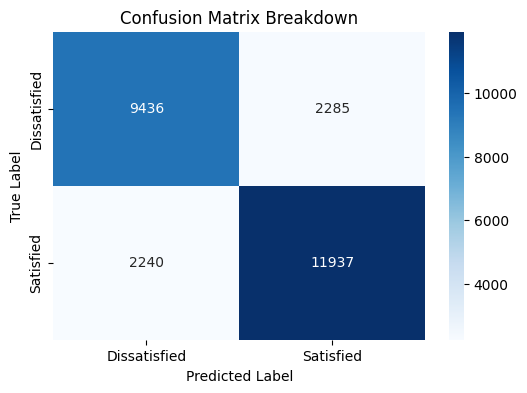

In [11]:
# Generate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Calculate key evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("--- Model Evaluation Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print("\nConfusion Matrix:")
print(cm)

# Optional: Visualize the confusion matrix cleanly using Seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Breakdown')
plt.show()

In [12]:
# Create a DataFrame to view the coefficients of each feature
coefficients_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

# Calculate the exponential of the coefficients to get the Odds Ratios
coefficients_df['Odds Ratio'] = np.exp(coefficients_df['Coefficient'])

# Sort by the absolute value of the coefficient to see the strongest drivers first
coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()
coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False).drop(columns=['Abs_Coefficient'])

print("--- Model Coefficients and Odds Ratios ---")
print(coefficients_df)

--- Model Coefficients and Odds Ratios ---
                              Feature  Coefficient  Odds Ratio
18    Customer Type_disloyal Customer    -1.890566    0.150986
7              Inflight entertainment     0.973634    2.647548
21                     Class_Eco Plus    -0.775057    0.460678
19     Type of Travel_Personal Travel    -0.758093    0.468559
20                          Class_Eco    -0.725599    0.484035
2                        Seat comfort     0.408756    1.504945
10                   On-board service     0.399074    1.490444
13                    Checkin service     0.357956    1.430403
3   Departure/Arrival time convenient    -0.332580    0.717071
9              Ease of Online booking     0.315901    1.371494
4                      Food and drink    -0.313184    0.731115
11                   Leg room service     0.310542    1.364164
17           Arrival Delay in Minutes    -0.304175    0.737731
15                    Online boarding     0.186024    1.204451
1           

In [13]:
from sklearn.metrics import classification_report

# Generate the complete classification report
report = classification_report(y_test, y_pred, target_names=['Dissatisfied', 'Satisfied'])

print("--- Scikit-Learn Classification Report ---")
print(report)

--- Scikit-Learn Classification Report ---
              precision    recall  f1-score   support

Dissatisfied       0.81      0.81      0.81     11721
   Satisfied       0.84      0.84      0.84     14177

    accuracy                           0.83     25898
   macro avg       0.82      0.82      0.82     25898
weighted avg       0.83      0.83      0.83     25898



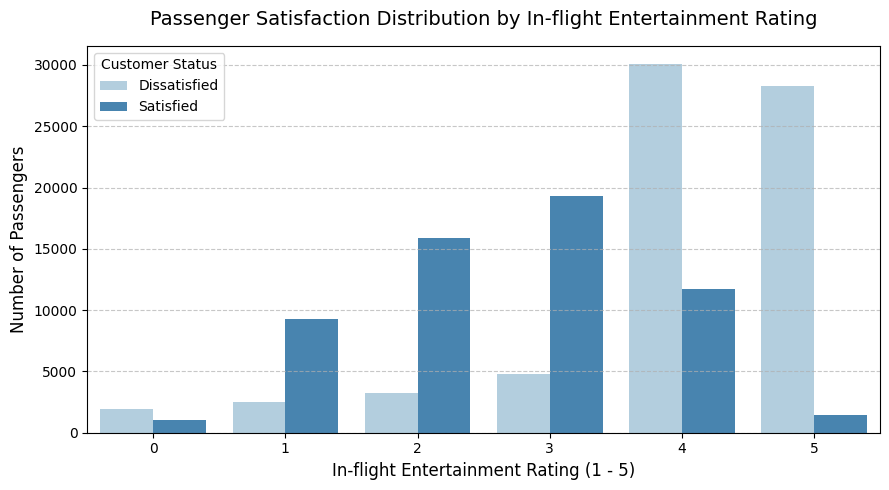

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

# Plotting the distribution of satisfaction across different entertainment ratings
sns.countplot(data=df, x='Inflight entertainment', hue='satisfaction', palette='Blues')

plt.title('Passenger Satisfaction Distribution by In-flight Entertainment Rating', fontsize=14, pad=15)
plt.xlabel('In-flight Entertainment Rating (1 - 5)', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.legend(title='Customer Status', labels=['Dissatisfied', 'Satisfied'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()